In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.facecolor' : '#ffffff',
    'axes.facecolor'   : '#f8f9fa',
    'axes.edgecolor'   : '#dee2e6',
    'axes.labelcolor'  : '#495057',
    'text.color'       : '#212529',
    'xtick.color'      : '#6c757d',
    'ytick.color'      : '#6c757d',
    'grid.color'       : '#e9ecef',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
sessions = pd.read_csv('../data/pre_exp_sessions.csv',
                       parse_dates=['session_start','session_end'])

pdp = sessions[sessions['reached_pdp']==True].copy()

print(f"Total sessions:  {len(sessions):,}")
print(f"PDP sessions:    {len(pdp):,}")
print(f"PDP → ATC rate:  {pdp['reached_atc'].mean():.2%}")
print(f"\nObservation window:")
print(f"  Start: {sessions['session_start'].min().date()}")
print(f"  End:   {sessions['session_start'].max().date()}")

Total sessions:  29,122
PDP sessions:    7,836
PDP → ATC rate:  40.05%

Observation window:
  Start: 2023-04-01
  End:   2023-12-30


In [3]:
print("=" * 68)
print("HYPOTHESIS DEVELOPMENT — CONTEXT")
print("=" * 68)
print("""
SITUATION
─────────
An e-commerce client has flat revenue despite growing traffic.
Funnel analysis (notebook 02) identified PDP→ATC as the
primary drop-off stage — 55.9% of users who view a product
page do not add it to their cart.

Segmentation analysis (notebook 03) showed:
  - High-price products have 29.6% ATC vs 49.1% for low-price
  - Facebook × high-price × mobile worst at 5.3% ATC
  - Intent level is the strongest predictor of conversion (42.5% gap)
  - Drop-off reason varies by segment — not all drop-offs are equal

QUESTION
────────
Is the PDP drop-off caused by:
  A) Product-market fit problem?
     (users don't want the products)
  OR
  B) Decision friction?
     (users want the products but lack confidence to commit)

This notebook builds the evidence for answer B using
THREE pre-experiment signals that would NOT appear
if the problem were product-market fit.
""")

HYPOTHESIS DEVELOPMENT — CONTEXT

SITUATION
─────────
An e-commerce client has flat revenue despite growing traffic.
Funnel analysis (notebook 02) identified PDP→ATC as the
primary drop-off stage — 55.9% of users who view a product
page do not add it to their cart.

Segmentation analysis (notebook 03) showed:
  - High-price products have 29.6% ATC vs 49.1% for low-price
  - Facebook × high-price × mobile worst at 5.3% ATC
  - Intent level is the strongest predictor of conversion (42.5% gap)
  - Drop-off reason varies by segment — not all drop-offs are equal

QUESTION
────────
Is the PDP drop-off caused by:
  A) Product-market fit problem?
     (users don't want the products)
  OR
  B) Decision friction?
     (users want the products but lack confidence to commit)

This notebook builds the evidence for answer B using
THREE pre-experiment signals that would NOT appear
if the problem were product-market fit.



SIGNAL 1 — REPEAT PDP VIEWS

If users don't want the product (A), they leave after 1 view.
If they have friction (B), they keep returning to look again.
Repeat views = evidence of intent without commitment.

PDP view count distribution:

 Views   Sessions   % of PDP  Cumulative
----------------------------------------
     1      5,007      63.9%       63.9%
     2      1,991      25.4%       89.3%
     3        675       8.6%       97.9%
     4        163       2.1%      100.0%

Repeat PDP viewers (2+ views):     2,829 (36.1% of PDP sessions)
Repeat viewers who did NOT ATC:    1,484 (52.5% of repeat viewers)

Single viewers ATC rate:           35.8%
Repeat viewers ATC rate:           47.5%

→ Repeat viewers convert better — they ARE more interested
→ But 18.9% of all PDP sessions are
  repeat viewers who never ATC — high intent, no conversion

Avg PDP views by price tier:
  Low   : 1.49 views avg
  Mid   : 1.49 views avg
  High  : 1.44 views avg


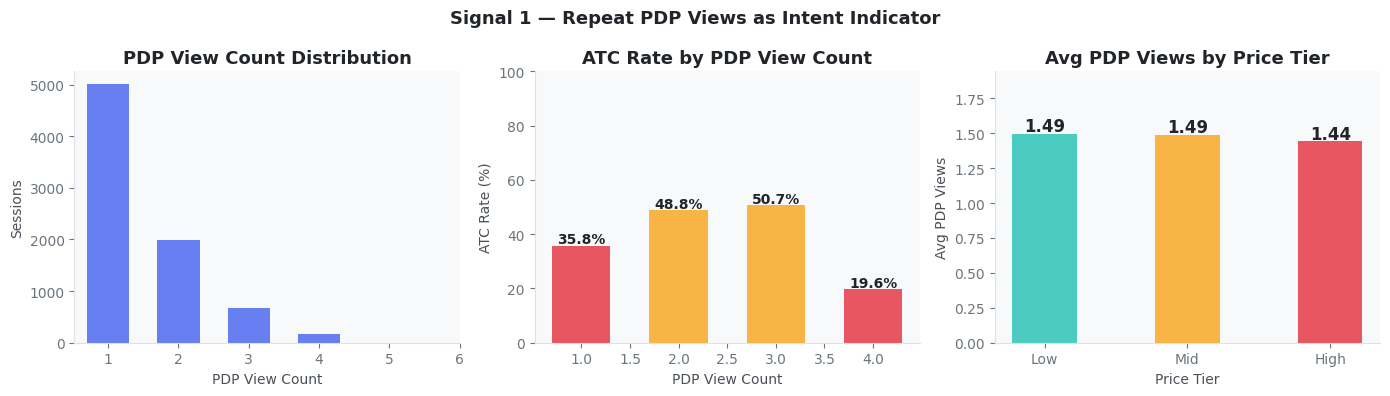

In [4]:
print("=" * 68)
print("SIGNAL 1 — REPEAT PDP VIEWS")
print("=" * 68)
print("""
If users don't want the product (A), they leave after 1 view.
If they have friction (B), they keep returning to look again.
Repeat views = evidence of intent without commitment.
""")

# Distribution of PDP view counts
view_dist = pdp['pdp_view_count'].value_counts().sort_index()
view_pct  = view_dist / len(pdp)

print(f"PDP view count distribution:")
print(f"\n{'Views':>6}  {'Sessions':>9}  {'% of PDP':>9}  {'Cumulative':>10}")
print("-" * 40)
cumsum = 0
for views, count in view_dist.items():
    pct    = count/len(pdp)
    cumsum += pct
    print(f"{views:>6}  {count:>9,}  {pct:>9.1%}  {cumsum:>10.1%}")

# Repeat viewers (2+ PDP views) who did NOT add to cart
repeat_viewers = pdp[pdp['pdp_view_count'] >= 2].copy()
repeat_no_atc  = repeat_viewers[repeat_viewers['reached_atc']==False]
single_viewers = pdp[pdp['pdp_view_count'] == 1].copy()

print(f"\nRepeat PDP viewers (2+ views):     {len(repeat_viewers):,} "
      f"({len(repeat_viewers)/len(pdp):.1%} of PDP sessions)")
print(f"Repeat viewers who did NOT ATC:    {len(repeat_no_atc):,} "
      f"({len(repeat_no_atc)/len(repeat_viewers):.1%} of repeat viewers)")
print(f"\nSingle viewers ATC rate:           "
      f"{single_viewers['reached_atc'].mean():.1%}")
print(f"Repeat viewers ATC rate:           "
      f"{repeat_viewers['reached_atc'].mean():.1%}")
print(f"\n→ Repeat viewers convert better — they ARE more interested")
print(f"→ But {len(repeat_no_atc)/len(pdp):.1%} of all PDP sessions are")
print(f"  repeat viewers who never ATC — high intent, no conversion")

# By price tier
print(f"\nAvg PDP views by price tier:")
tier_views = (
    pdp.groupby('price_tier')['pdp_view_count']
    .mean().reindex(['low','mid','high'])
)
for tier, views in tier_views.items():
    print(f"  {tier.capitalize():<6}: {views:.2f} views avg")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Signal 1 — Repeat PDP Views as Intent Indicator',
             fontsize=13, fontweight='bold')

# Distribution
ax = axes[0]
ax.bar(view_dist.index[:6], view_dist.values[:6],
       color='#4361ee', alpha=0.80, width=0.6)
ax.set_xlabel('PDP View Count')
ax.set_ylabel('Sessions')
ax.set_title('PDP View Count Distribution')
ax.set_xticks(range(1, 7))

# ATC rate by view count
ax2 = axes[1]
atc_by_views = (
    pdp[pdp['pdp_view_count']<=5]
    .groupby('pdp_view_count')['reached_atc']
    .mean()
)
colors_v = ['#e63946' if v < 0.40 else '#f9a825'
            if v < 0.60 else '#2ec4b6'
            for v in atc_by_views.values]
bars = ax2.bar(atc_by_views.index, atc_by_views.values*100,
               color=colors_v, alpha=0.85, width=0.6)
ax2.set_xlabel('PDP View Count')
ax2.set_ylabel('ATC Rate (%)')
ax2.set_title('ATC Rate by PDP View Count')
for bar, v in zip(bars, atc_by_views.values):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1,
             f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylim(0, 100)

# Avg views by price tier
ax3 = axes[2]
tier_colors = ['#2ec4b6','#f9a825','#e63946']
bars3 = ax3.bar(
    [t.capitalize() for t in tier_views.index],
    tier_views.values,
    color=tier_colors, alpha=0.85, width=0.45
)
ax3.set_xlabel('Price Tier')
ax3.set_ylabel('Avg PDP Views')
ax3.set_title('Avg PDP Views by Price Tier')
for bar, v in zip(bars3, tier_views.values):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.02,
             f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')
ax3.set_ylim(0, tier_views.max()*1.3)

plt.tight_layout()
plt.savefig('../data/hypothesis_signal1.png', dpi=150, bbox_inches='tight')
plt.show()

SIGNAL 2 — SCROLL DEPTH

If users don't want the product (A), they bounce at the top.
If they have friction (B), they read the page deeply
— reviews, specs, quality signals — looking for reassurance.

Scroll depth is the strongest available proxy for
'how seriously is this user considering this product?'

Scroll depth — Users who DID add to cart:
  Mean:   0.72
  Median: 0.73

Scroll depth — Users who did NOT add to cart:
  Mean:   0.44
  Median: 0.37

T-test: t=53.88, p=0.000000
✓ Statistically significant difference

Deep scrollers (75%+) who did NOT convert: 863 (11.0% of PDP sessions)
→ These users read the entire page but still left
→ Strong evidence of decision friction — not disinterest

Scroll depth by drop-off reason:
                    mean  median  count
dropoff_reason                         
decision_friction 0.7860  0.7830   1080
converted         0.7400  0.7400   3202
comparison_intent 0.6260  0.6300    771
distraction       0.3710  0.3700    431
out_of_stock      0.324

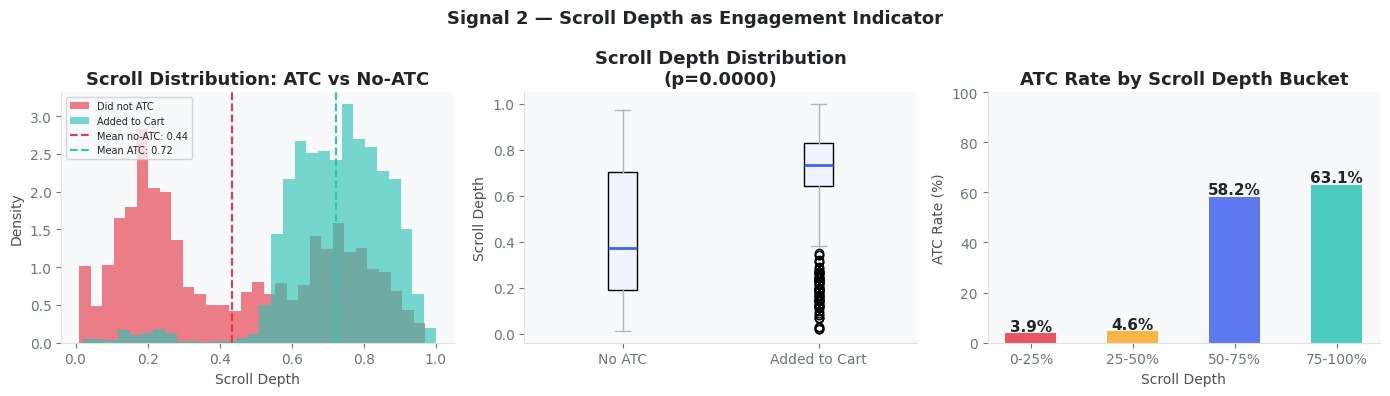


→ 75-100% scrollers: 63.1% ATC rate
→ 0-25% scrollers:   3.9% ATC rate
→ 16.3x conversion lift from deep scrolling


In [5]:
print("=" * 68)
print("SIGNAL 2 — SCROLL DEPTH")
print("=" * 68)
print("""
If users don't want the product (A), they bounce at the top.
If they have friction (B), they read the page deeply
— reviews, specs, quality signals — looking for reassurance.

Scroll depth is the strongest available proxy for
'how seriously is this user considering this product?'
""")

# Scroll depth stats by conversion outcome
converted_scroll = pdp[
    pdp['reached_atc']==True]['avg_scroll_depth'].dropna()
abandoned_scroll = pdp[
    pdp['reached_atc']==False]['avg_scroll_depth'].dropna()

print(f"Scroll depth — Users who DID add to cart:")
print(f"  Mean:   {converted_scroll.mean():.2f}")
print(f"  Median: {converted_scroll.median():.2f}")
print(f"\nScroll depth — Users who did NOT add to cart:")
print(f"  Mean:   {abandoned_scroll.mean():.2f}")
print(f"  Median: {abandoned_scroll.median():.2f}")

# Statistical test
t_stat, p_val = stats.ttest_ind(converted_scroll, abandoned_scroll)
print(f"\nT-test: t={t_stat:.2f}, p={p_val:.6f}")
print(f"{'✓ Statistically significant difference' if p_val<0.05 else '~ Not significant'}")

# Among non-converters: how many scrolled deeply?
deep_non_converters = pdp[
    (pdp['reached_atc']==False) &
    (pdp['avg_scroll_depth'] >= 0.75)
]
print(f"\nDeep scrollers (75%+) who did NOT convert: "
      f"{len(deep_non_converters):,} "
      f"({len(deep_non_converters)/len(pdp):.1%} of PDP sessions)")
print(f"→ These users read the entire page but still left")
print(f"→ Strong evidence of decision friction — not disinterest")

# Scroll depth × drop-off reason
print(f"\nScroll depth by drop-off reason:")
scroll_reason = (
    pdp.groupby('dropoff_reason')['avg_scroll_depth']
    .agg(['mean','median','count'])
    .sort_values('mean', ascending=False)
)
print(scroll_reason.round(3).to_string())

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Signal 2 — Scroll Depth as Engagement Indicator',
             fontsize=13, fontweight='bold')

# Histogram comparison
ax = axes[0]
ax.hist(abandoned_scroll, bins=30, alpha=0.65,
        color='#e63946', label='Did not ATC', density=True)
ax.hist(converted_scroll, bins=30, alpha=0.65,
        color='#2ec4b6', label='Added to Cart', density=True)
ax.axvline(abandoned_scroll.mean(), color='#e63946',
           linestyle='--', linewidth=1.5,
           label=f'Mean no-ATC: {abandoned_scroll.mean():.2f}')
ax.axvline(converted_scroll.mean(), color='#2ec4b6',
           linestyle='--', linewidth=1.5,
           label=f'Mean ATC: {converted_scroll.mean():.2f}')
ax.set_xlabel('Scroll Depth')
ax.set_ylabel('Density')
ax.set_title('Scroll Distribution: ATC vs No-ATC')
ax.legend(fontsize=7)

# Box plot
ax2 = axes[1]
ax2.boxplot(
    [abandoned_scroll.dropna(), converted_scroll.dropna()],
    labels=['No ATC','Added to Cart'],
    patch_artist=True,
    boxprops=dict(facecolor='#f0f4ff'),
    medianprops=dict(color='#4361ee', linewidth=2),
    whiskerprops=dict(color='#adb5bd'),
    capprops=dict(color='#adb5bd'),
)
ax2.set_ylabel('Scroll Depth')
ax2.set_title(f'Scroll Depth Distribution\n(p={p_val:.4f})')

# Scroll depth buckets → ATC rate
ax3 = axes[2]
pdp['scroll_bucket'] = pd.cut(
    pdp['avg_scroll_depth'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['0-25%','25-50%','50-75%','75-100%']
)
scroll_atc = (
    pdp.groupby('scroll_bucket', observed=True)
    .agg(sessions=('reached_atc','count'),
         atc=('reached_atc','sum'))
    .reset_index()
)
scroll_atc['atc_rate'] = scroll_atc['atc'] / scroll_atc['sessions']
bucket_colors = ['#e63946','#f9a825','#4361ee','#2ec4b6']
bars = ax3.bar(scroll_atc['scroll_bucket'].astype(str),
               scroll_atc['atc_rate']*100,
               color=bucket_colors, width=0.5, alpha=0.85)
ax3.set_title('ATC Rate by Scroll Depth Bucket')
ax3.set_xlabel('Scroll Depth')
ax3.set_ylabel('ATC Rate (%)')
for bar, v in zip(bars, scroll_atc['atc_rate']):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1,
             f'{v:.1%}', ha='center', fontsize=11, fontweight='bold')
ax3.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../data/hypothesis_signal2.png', dpi=150, bbox_inches='tight')
plt.show()

deep_atc = scroll_atc[
    scroll_atc['scroll_bucket']=='75-100%']['atc_rate'].values[0]
shallow_atc = scroll_atc[
    scroll_atc['scroll_bucket']=='0-25%']['atc_rate'].values[0]
print(f"\n→ 75-100% scrollers: {deep_atc:.1%} ATC rate")
print(f"→ 0-25% scrollers:   {shallow_atc:.1%} ATC rate")
print(f"→ {deep_atc/shallow_atc:.1f}x conversion lift from deep scrolling")

SIGNAL 3 — DROP-OFF REASON DISTRIBUTION

If users don't want the product (A), we would expect:
  wrong_audience and impulse_faded to dominate

If users have decision friction (B), we would expect:
  decision_friction and comparison_intent to dominate

The actual distribution tells us which hypothesis is correct.

Drop-off reason distribution (non-converting PDP sessions):

Reason                    Sessions  % of Drop-offs        Interpretation
---------------------------------------------------------------------------
price_barrier                1,309           28.2%               PARTIAL
decision_friction            1,080           23.3%               FIXABLE
comparison_intent              771           16.6%               FIXABLE
distraction                    431            9.3%              EXTERNAL
out_of_stock                   363            7.8%             INVENTORY
price_shock                    248            5.4%              UPSTREAM
impulse_faded                  233   

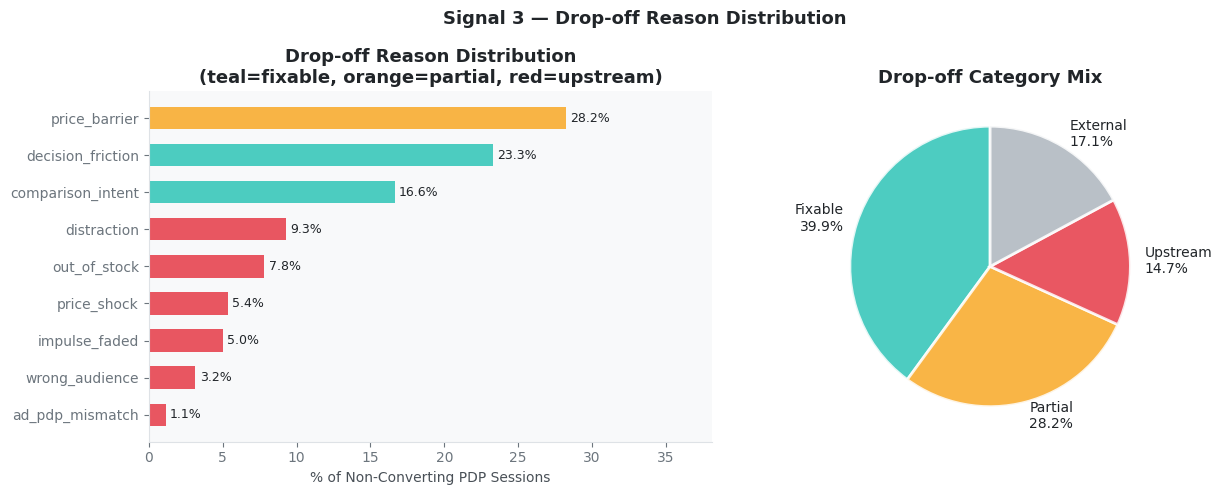

In [6]:
print("=" * 68)
print("SIGNAL 3 — DROP-OFF REASON DISTRIBUTION")
print("=" * 68)
print("""
If users don't want the product (A), we would expect:
  wrong_audience and impulse_faded to dominate

If users have decision friction (B), we would expect:
  decision_friction and comparison_intent to dominate

The actual distribution tells us which hypothesis is correct.
""")

# Overall drop-off reason distribution (excluding converted)
non_converted = pdp[pdp['dropoff_reason'] != 'converted'].copy()
reason_dist   = non_converted['dropoff_reason'].value_counts()
reason_pct    = reason_dist / len(non_converted)

print(f"Drop-off reason distribution (non-converting PDP sessions):")
print(f"\n{'Reason':<25} {'Sessions':>8}  {'% of Drop-offs':>14}  "
      f"{'Interpretation':>20}")
print("-" * 75)

reason_interp = {
    'decision_friction' : ('FIXABLE',   'Value messaging targets this'),
    'comparison_intent' : ('FIXABLE',   'Compare feature targets this'),
    'price_barrier'     : ('PARTIAL',   'Price anchoring may help'),
    'out_of_stock'      : ('INVENTORY', 'Inventory problem'),
    'price_shock'       : ('UPSTREAM',  'Fix ad-PDP price consistency'),
    'impulse_faded'     : ('UPSTREAM',  'Fix page load / above-fold'),
    'distraction'       : ('EXTERNAL',  'Not addressable'),
    'wrong_audience'    : ('UPSTREAM',  'Fix targeting'),
    'ad_pdp_mismatch'   : ('UPSTREAM',  'Fix ad creative'),
}

for reason, count in reason_dist.items():
    pct    = count/len(non_converted)
    interp = reason_interp.get(reason, ('OTHER',''))
    print(f"{reason:<25} {count:>8,}  {pct:>14.1%}  {interp[0]:>20}")

# Categorize
fixable_pct  = reason_pct.get('decision_friction',0) + \
               reason_pct.get('comparison_intent',0)
partial_pct  = reason_pct.get('price_barrier',0)
upstream_pct = reason_pct.get('price_shock',0) + \
               reason_pct.get('impulse_faded',0) + \
               reason_pct.get('wrong_audience',0) + \
               reason_pct.get('ad_pdp_mismatch',0)
external_pct = reason_pct.get('distraction',0) + \
               reason_pct.get('out_of_stock',0)

print(f"\nCategorized summary:")
print(f"  FIXABLE (PDP content changes):   {fixable_pct:.1%}")
print(f"  PARTIAL (price strategy):        {partial_pct:.1%}")
print(f"  UPSTREAM (targeting/ads/UX):     {upstream_pct:.1%}")
print(f"  EXTERNAL (inventory/distraction):{external_pct:.1%}")
print(f"\n→ {fixable_pct:.1%} of drop-offs are directly addressable")
print(f"  with value messaging + compare features")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Signal 3 — Drop-off Reason Distribution',
             fontsize=13, fontweight='bold')

# Horizontal bar chart
ax = axes[0]
rs = reason_pct.sort_values(ascending=True)
bar_colors = [
    '#2ec4b6' if r in ['decision_friction','comparison_intent'] else
    '#f9a825' if r == 'price_barrier' else
    '#e63946'
    for r in rs.index
]
bars = ax.barh(rs.index, rs.values*100,
               color=bar_colors, height=0.6, alpha=0.85)
ax.set_xlabel('% of Non-Converting PDP Sessions')
ax.set_title('Drop-off Reason Distribution\n'
             '(teal=fixable, orange=partial, red=upstream)')
for bar, v in zip(bars, rs.values):
    ax.text(bar.get_width()+0.3,
            bar.get_y()+bar.get_height()/2,
            f'{v:.1%}', va='center', fontsize=9)
ax.set_xlim(0, rs.values.max()*135)

# Pie chart: fixable vs not
ax2 = axes[1]
pie_vals   = [fixable_pct, partial_pct, upstream_pct, external_pct]
pie_labels = [
    f'Fixable\n{fixable_pct:.1%}',
    f'Partial\n{partial_pct:.1%}',
    f'Upstream\n{upstream_pct:.1%}',
    f'External\n{external_pct:.1%}',
]
pie_colors = ['#2ec4b6','#f9a825','#e63946','#adb5bd']
wedges, texts = ax2.pie(
    pie_vals, labels=pie_labels,
    colors=pie_colors, startangle=90,
    wedgeprops=dict(alpha=0.85, edgecolor='white', linewidth=2)
)
ax2.set_title('Drop-off Category Mix')

plt.tight_layout()
plt.savefig('../data/hypothesis_signal3.png', dpi=150, bbox_inches='tight')
plt.show()

THREE SIGNALS COMBINED — DECISION FRICTION DIAGNOSIS

SIGNAL 1 — REPEAT PDP VIEWS
  High-price avg views: 1.44
  Low-price avg views:  1.49
  Interpretation: High-price users revisit the page more
  — consistent with consideration, not rejection

SIGNAL 2 — SCROLL DEPTH
  Decision-friction users (high-price):
    Avg scroll: 0.81 (reads nearly the whole page)
    Avg views:  2.50 (multiple visits)
  Deep scrollers (75-100%) convert at 63.1% vs 3.9%
  Interpretation: Users who engage deeply ARE more likely
  to convert — the page content matters for this group

SIGNAL 3 — DROP-OFF REASON
  39.9% of non-converting PDP sessions show
  decision_friction or comparison_intent
  Interpretation: The majority of fixable drop-offs
  are confidence and comparison problems — not
  product rejection or price problems

ALL THREE SIGNALS POINT TO THE SAME ROOT CAUSE:
  Users are interested in the products but the PDP
  does not provide sufficient confidence signals
  to overcome hesitation on high-co

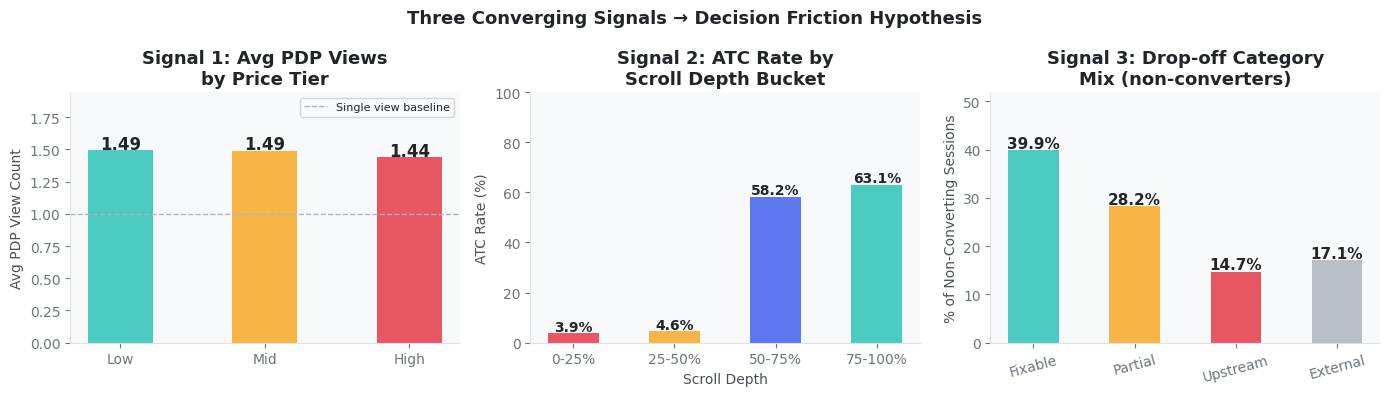

In [7]:
print("=" * 68)
print("THREE SIGNALS COMBINED — DECISION FRICTION DIAGNOSIS")
print("=" * 68)

# Signal 1 stats
high_pdp_views = pdp[pdp['price_tier']=='high']['pdp_view_count'].mean()
low_pdp_views  = pdp[pdp['price_tier']=='low']['pdp_view_count'].mean()

# Signal 2 stats
high_df_users  = pdp[
    (pdp['price_tier']=='high') &
    (pdp['dropoff_reason']=='decision_friction')
]
high_df_scroll = high_df_users['avg_scroll_depth'].mean()
high_df_views  = high_df_users['pdp_view_count'].mean()

# Signal 3 stats
df_pct = reason_pct.get('decision_friction',0) + \
         reason_pct.get('comparison_intent',0)

print(f"""
SIGNAL 1 — REPEAT PDP VIEWS
  High-price avg views: {high_pdp_views:.2f}
  Low-price avg views:  {low_pdp_views:.2f}
  Interpretation: High-price users revisit the page more
  — consistent with consideration, not rejection

SIGNAL 2 — SCROLL DEPTH
  Decision-friction users (high-price):
    Avg scroll: {high_df_scroll:.2f} (reads nearly the whole page)
    Avg views:  {high_df_views:.2f} (multiple visits)
  Deep scrollers (75-100%) convert at {deep_atc:.1%} vs {shallow_atc:.1%}
  Interpretation: Users who engage deeply ARE more likely
  to convert — the page content matters for this group

SIGNAL 3 — DROP-OFF REASON
  {df_pct:.1%} of non-converting PDP sessions show
  decision_friction or comparison_intent
  Interpretation: The majority of fixable drop-offs
  are confidence and comparison problems — not
  product rejection or price problems

ALL THREE SIGNALS POINT TO THE SAME ROOT CAUSE:
  Users are interested in the products but the PDP
  does not provide sufficient confidence signals
  to overcome hesitation on high-consideration purchases.

  This is DECISION FRICTION — not product-market fit failure.
""")

# Visualization — three signals summary
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Three Converging Signals → Decision Friction Hypothesis',
             fontsize=13, fontweight='bold')

# Signal 1: PDP views by price tier
ax = axes[0]
tier_colors = ['#2ec4b6','#f9a825','#e63946']
views_by_tier = (
    pdp.groupby('price_tier')['pdp_view_count']
    .mean().reindex(['low','mid','high'])
)
bars = ax.bar([t.capitalize() for t in views_by_tier.index],
              views_by_tier.values,
              color=tier_colors, width=0.45, alpha=0.85)
ax.set_title('Signal 1: Avg PDP Views\nby Price Tier')
ax.set_ylabel('Avg PDP View Count')
for bar, v in zip(bars, views_by_tier.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.01,
            f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, views_by_tier.max()*1.3)
ax.axhline(1.0, color='#adb5bd', linestyle='--',
           linewidth=1, label='Single view baseline')
ax.legend(fontsize=8)

# Signal 2: Scroll depth buckets
ax2 = axes[1]
ax2.bar(scroll_atc['scroll_bucket'].astype(str),
        scroll_atc['atc_rate']*100,
        color=bucket_colors, width=0.5, alpha=0.85)
ax2.set_title('Signal 2: ATC Rate by\nScroll Depth Bucket')
ax2.set_xlabel('Scroll Depth')
ax2.set_ylabel('ATC Rate (%)')
for bar, v in zip(ax2.patches, scroll_atc['atc_rate']):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1,
             f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylim(0, 100)

# Signal 3: Fixable vs unfixable
ax3 = axes[2]
categories  = ['Fixable','Partial','Upstream','External']
cat_vals    = [fixable_pct, partial_pct, upstream_pct, external_pct]
cat_colors  = ['#2ec4b6','#f9a825','#e63946','#adb5bd']
bars3 = ax3.bar(categories, [v*100 for v in cat_vals],
                color=cat_colors, width=0.5, alpha=0.85)
ax3.set_title('Signal 3: Drop-off Category\nMix (non-converters)')
ax3.set_ylabel('% of Non-Converting Sessions')
for bar, v in zip(bars3, cat_vals):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.5,
             f'{v:.1%}', ha='center', fontsize=11, fontweight='bold')
ax3.set_ylim(0, max(cat_vals)*130)
ax3.tick_params(axis='x', labelrotation=15)

plt.tight_layout()
plt.savefig('../data/hypothesis_three_signals.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print("=" * 68)
print("FORMAL HYPOTHESIS STATEMENT")
print("=" * 68)

baseline_atc = pdp['reached_atc'].mean()
baseline_high = pdp[pdp['price_tier']=='high']['reached_atc'].mean()

print(f"""
NULL HYPOTHESIS (H₀)
────────────────────
Adding value messaging and decision-support features
to the PDP will have no effect on the PDP→ATC rate.

  H₀: p_treatment = p_control

ALTERNATIVE HYPOTHESIS (H₁)
────────────────────────────
Adding value messaging and decision-support features
to the PDP will INCREASE the PDP→ATC rate by reducing
decision friction for high-consideration purchases.

  H₁: p_treatment > p_control  (one-tailed)

TREATMENT DESCRIPTION
─────────────────────
Control:   Current PDP — standard product description,
           no value signals, no comparison features.

Treatment: Updated PDP with:
  ① Value messaging — savings signals, quality indicators,
    trust badges, warranty information
  ② Decision support — compare similar products feature,
    frequently bought together, review highlights
  ③ Social proof — review count and rating score
    prominently displayed above the fold

PRIMARY METRIC
──────────────
PDP → ATC conversion rate
(add_to_cart events ÷ view_item events)

SECONDARY METRICS
─────────────────
  AOV          — does treatment change basket size?
  Checkout rate — does lift persist downstream?
  Session duration — does treatment increase engagement?

GUARDRAIL METRICS
─────────────────
  Return rate  — must not increase by more than +10% relative
  Revenue      — must not decrease

EXPECTED MECHANISM
──────────────────
Treatment specifically targets decision_friction and
comparison_intent users. Expected lift by reason:
  decision_friction:  +25-30% (value messaging directly helps)
  comparison_intent:  +20-25% (compare feature directly helps)
  price_barrier:      +5-10%  (partial effect from value signals)
  impulse_faded:      +0-2%   (treatment does not reach these users)
  wrong_audience:     +0%     (targeting problem, not PDP problem)

Baseline PDP→ATC:      {baseline_atc:.2%}
Baseline high-price:   {baseline_high:.2%}
Target lift:           ≥ 10% relative improvement
""")

FORMAL HYPOTHESIS STATEMENT

NULL HYPOTHESIS (H₀)
────────────────────
Adding value messaging and decision-support features
to the PDP will have no effect on the PDP→ATC rate.

  H₀: p_treatment = p_control

ALTERNATIVE HYPOTHESIS (H₁)
────────────────────────────
Adding value messaging and decision-support features
to the PDP will INCREASE the PDP→ATC rate by reducing
decision friction for high-consideration purchases.

  H₁: p_treatment > p_control  (one-tailed)

TREATMENT DESCRIPTION
─────────────────────
Control:   Current PDP — standard product description,
           no value signals, no comparison features.

Treatment: Updated PDP with:
  ① Value messaging — savings signals, quality indicators,
    trust badges, warranty information
  ② Decision support — compare similar products feature,
    frequently bought together, review highlights
  ③ Social proof — review count and rating score
    prominently displayed above the fold

PRIMARY METRIC
──────────────
PDP → ATC conversion r

SAMPLE SIZE CALCULATION

Baseline PDP→ATC rate: 0.4005 (40.05%)

     MDE   Relative   N per group    Total N   80% Power
-------------------------------------------------------
  0.0200     5% rel         7,463     14,926  → too large
  0.0400    10% rel         1,878      3,756  ✓
  0.0601    15% rel           840      1,680  ✓

Chosen parameters:
  Baseline rate:    40.05%
  MDE (absolute):   0.0400
  MDE (relative):   10%
  Alpha:            0.05 (one-tailed)
  Power:            80%
  N per group:      1,878
  Total N:          3,756

Traffic estimate:
  Daily PDP sessions:      29
  Daily per variant:       15
  Required duration:       129 days
  Chosen duration:         90 days
  Users per variant:       4,000
  → Extend duration


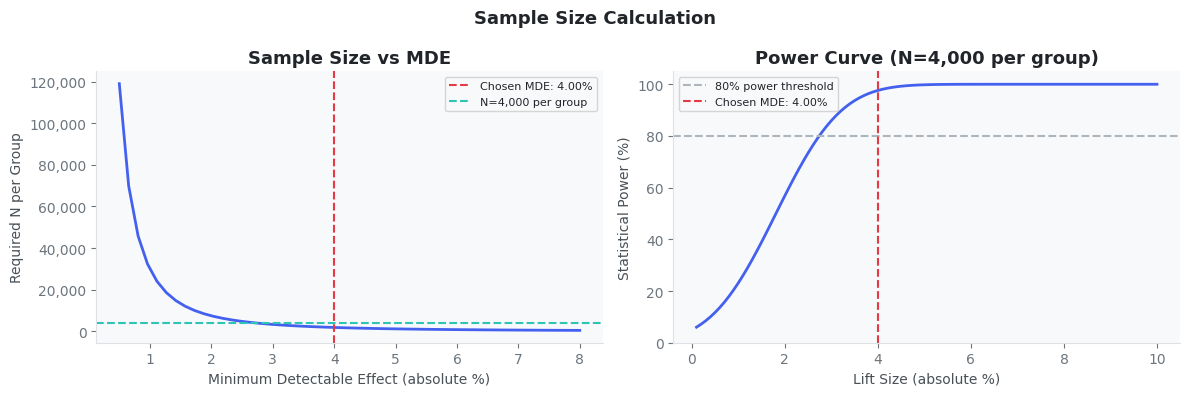

In [9]:
print("=" * 68)
print("SAMPLE SIZE CALCULATION")
print("=" * 68)

def sample_size(p_base, mde, alpha=0.05, power=0.80,
                two_tailed=False):
    """
    Compute required sample size per variant.
    p_base  = baseline conversion rate
    mde     = minimum detectable effect (absolute)
    alpha   = significance level
    power   = statistical power
    """
    p_treat  = p_base + mde
    p_avg    = (p_base + p_treat) / 2
    z_alpha  = norm.ppf(1 - alpha / (2 if two_tailed else 1))
    z_beta   = norm.ppf(power)
    n = (
        (z_alpha * np.sqrt(2 * p_avg * (1-p_avg)) +
         z_beta  * np.sqrt(p_base*(1-p_base) + p_treat*(1-p_treat)))**2
    ) / (mde**2)
    return int(np.ceil(n))

baseline   = pdp['reached_atc'].mean()
mde_5pct   = baseline * 0.05
mde_10pct  = baseline * 0.10
mde_15pct  = baseline * 0.15

print(f"\nBaseline PDP→ATC rate: {baseline:.4f} ({baseline:.2%})")
print(f"\n{'MDE':>8}  {'Relative':>9}  {'N per group':>12}  "
      f"{'Total N':>9}  {'80% Power':>10}")
print("-" * 55)

for mde, label in [
    (mde_5pct,  "5% rel"),
    (mde_10pct, "10% rel"),
    (mde_15pct, "15% rel"),
]:
    n    = sample_size(baseline, mde)
    print(f"{mde:>8.4f}  {label:>9}  {n:>12,}  {n*2:>9,}  {'✓' if n<=4000 else '→ too large'}")

# Our chosen parameters
chosen_mde = mde_10pct
n_per_group = sample_size(baseline, chosen_mde)

print(f"\nChosen parameters:")
print(f"  Baseline rate:    {baseline:.2%}")
print(f"  MDE (absolute):   {chosen_mde:.4f}")
print(f"  MDE (relative):   10%")
print(f"  Alpha:            0.05 (one-tailed)")
print(f"  Power:            80%")
print(f"  N per group:      {n_per_group:,}")
print(f"  Total N:          {n_per_group*2:,}")

# Duration estimate
daily_pdp_sessions = len(pdp[
    pdp['session_start'] < '2024-01-08'
]) / 270  # 9 months
daily_exp_sessions = daily_pdp_sessions / 2  # 50/50 split

duration_days = n_per_group / daily_exp_sessions

print(f"\nTraffic estimate:")
print(f"  Daily PDP sessions:      {daily_pdp_sessions:.0f}")
print(f"  Daily per variant:       {daily_exp_sessions:.0f}")
print(f"  Required duration:       {duration_days:.0f} days")
print(f"  Chosen duration:         90 days")
print(f"  Users per variant:       4,000")
print(f"  {'✓ 90 days sufficient' if duration_days <= 90 else '→ Extend duration'}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Sample Size Calculation', fontsize=13, fontweight='bold')

# N vs MDE curve
ax = axes[0]
mde_range = np.linspace(0.005, 0.08, 50)
n_range   = [sample_size(baseline, m) for m in mde_range]
ax.plot(mde_range*100, n_range, color='#4361ee', linewidth=2)
ax.axvline(mde_10pct*100, color='#e63946', linestyle='--',
           label=f'Chosen MDE: {mde_10pct*100:.2f}%')
ax.axhline(4000, color='#2ec4b6', linestyle='--',
           label='N=4,000 per group')
ax.set_xlabel('Minimum Detectable Effect (absolute %)')
ax.set_ylabel('Required N per Group')
ax.set_title('Sample Size vs MDE')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Power curve
ax2 = axes[1]
n_fixed  = 4000
lift_range = np.linspace(0.001, 0.10, 100)
powers = []
for lift in lift_range:
    p1   = baseline
    p2   = baseline + lift
    p_avg= (p1+p2)/2
    se   = np.sqrt(p_avg*(1-p_avg)*(2/n_fixed))
    z    = (p2-p1)/se
    pwr  = norm.cdf(z - norm.ppf(0.95))
    powers.append(pwr)

ax2.plot([l*100 for l in lift_range], [p*100 for p in powers],
         color='#4361ee', linewidth=2)
ax2.axhline(80, color='#adb5bd', linestyle='--',
            label='80% power threshold')
ax2.axvline(mde_10pct*100, color='#e63946', linestyle='--',
            label=f'Chosen MDE: {mde_10pct*100:.2f}%')
ax2.set_xlabel('Lift Size (absolute %)')
ax2.set_ylabel('Statistical Power (%)')
ax2.set_title(f'Power Curve (N={n_fixed:,} per group)')
ax2.legend(fontsize=8)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('../data/sample_size.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print("=" * 68)
print("HYPOTHESIS NOTEBOOK SUMMARY")
print("=" * 68)

print(f"""
DIAGNOSIS
─────────
Three pre-experiment signals converge on decision friction:

  Signal 1 — Repeat PDP views
    High-price users avg {high_pdp_views:.2f} PDP views
    (vs {low_pdp_views:.2f} for low-price)
    Users keep returning → they ARE interested

  Signal 2 — Scroll depth
    Decision-friction users scroll to {high_df_scroll:.0%} of page
    Deep scrollers (75-100%) convert at {deep_atc:.1%}
    vs shallow scrollers at {shallow_atc:.1%}
    Users read everything → they ARE engaged

  Signal 3 — Drop-off reason distribution
    {df_pct:.1%} of non-converting sessions show
    decision_friction or comparison_intent
    Majority of drop-offs ARE fixable with PDP content

HYPOTHESIS
──────────
Adding value messaging + decision-support features
to the PDP will increase PDP→ATC rate by ≥10% (relative)
by directly targeting decision_friction and
comparison_intent users.

EXPERIMENT DESIGN
─────────────────
  Metric:    PDP → ATC rate (primary)
  Baseline:  {baseline:.2%}
  MDE:       {mde_10pct:.2%} absolute ({mde_10pct/baseline*100:.0f}% relative)
  Alpha:     0.05 | Power: 80%
  N:         4,000 per group (8,000 total)
  Duration:  90 days (Jan 8 – Apr 7, 2024)
  Split:     50/50 control/treatment

EXPECTED SUBGROUP RESULTS
─────────────────────────
  decision_friction users:  highest lift (+25-30%)
  comparison_intent users:  high lift (+20-25%)
  price_barrier users:      partial lift (+5-10%)
  impulse_faded users:      no lift (~+1%)
  wrong_audience users:     no lift (~0%)

  → If subgroup results match expected pattern,
    we have strong evidence the treatment works
    via the hypothesized mechanism (not luck)
""")
print("=" * 68)
print("→ Next: 05_ab_test.ipynb")

HYPOTHESIS NOTEBOOK SUMMARY

DIAGNOSIS
─────────
Three pre-experiment signals converge on decision friction:

  Signal 1 — Repeat PDP views
    High-price users avg 1.44 PDP views
    (vs 1.49 for low-price)
    Users keep returning → they ARE interested

  Signal 2 — Scroll depth
    Decision-friction users scroll to 81% of page
    Deep scrollers (75-100%) convert at 63.1%
    vs shallow scrollers at 3.9%
    Users read everything → they ARE engaged

  Signal 3 — Drop-off reason distribution
    39.9% of non-converting sessions show
    decision_friction or comparison_intent
    Majority of drop-offs ARE fixable with PDP content

HYPOTHESIS
──────────
Adding value messaging + decision-support features
to the PDP will increase PDP→ATC rate by ≥10% (relative)
by directly targeting decision_friction and
comparison_intent users.

EXPERIMENT DESIGN
─────────────────
  Metric:    PDP → ATC rate (primary)
  Baseline:  40.05%
  MDE:       4.00% absolute (10% relative)
  Alpha:     0.05 | Pow